# DISCO convolutions on the sphere

This guide explains the **discrete-continuous (DISCO)** convolution
implemented in
{class}`~torch_harmonics.DiscreteContinuousConvS2`.
We start with the mathematical formulation, show how the filter basis
functions look, and walk through a concrete convolution example.

## 1. Convolution on the sphere

A convolution on $S^2$ generalises the familiar planar convolution by
replacing translations with rotations.  Given a multi-channel input signal
$f^{c_i}(\omega)$ and a filter $\kappa$ centred at the north pole, the
output at point $\omega'$ is

$$
g^{c_o}(\omega')
    = \sum_{c_i} \int_{S^2}
      \kappa^{c_o,c_i}\!\bigl(R_{\omega'}^{-1}\,\omega\bigr)\;
      f^{c_i}(\omega)\;\mathrm{d}\omega
$$

where $\omega = (\theta, \lambda)$ are coordinates on the sphere and
$R_{\omega'}$ is the rotation that maps the north pole to the output
point $\omega'$.
Evaluating this integral naively for all output points would be $O(N^2)$
in the number of grid points.

### Making it tractable

The DISCO approach
([Ocampo, Price & McEwen, ICLR 2023](https://arxiv.org/abs/2209.13603))
makes two key choices:

1. **Compact support** -- the filter $\kappa$ is non-zero only within an
   angular cap of radius `theta_cutoff` around the north pole.  This means
   each output point only "sees" a small, fixed-size neighbourhood of input
   points, reducing the cost to $O(N)$.

2. **Continuous parameterisation** -- the filter is expressed as a learnable
   linear combination of fixed basis functions $\{\phi_k\}$:

$$
\kappa^{c_o, c_i}(\vartheta, \varphi)
    = \sum_{k=0}^{K-1} w_k^{c_o, c_i}\;\phi_k(\vartheta, \varphi)
$$

   where $\vartheta$ is the angular distance from the filter centre and
   $\varphi$ the azimuthal angle.  Because the filter is defined
   continuously (not on a fixed grid), the same weights $w_k$ can be
   evaluated on different input/output resolutions.

## 2. The $\Psi$ convolution tensor

To evaluate the integral numerically, the basis functions $\phi_k$ are
sampled at the rotated positions of the input grid points.  For each output
latitude $\theta'_j$, the rotation $R_{\omega'_j}^{-1}$ maps each input
point $(\theta_i, \lambda_p)$ into the filter's local frame.  The basis
function values at those positions, multiplied by the quadrature weights
$q_i$, form the sparse **convolution tensor**:

$$
\Psi_{k,\,j,\,(i,p)}
    = \phi_k\!\bigl(\vartheta(\theta'_j, \theta_i, \lambda_p),\;
                    \varphi(\theta'_j, \theta_i, \lambda_p)\bigr)
      \; q_i
$$

Two important properties make this efficient:

- **Sparsity**: because of the compact support, most entries of $\Psi$ are
  zero.  Only the input points that fall inside the angular cap contribute.

- **Longitude invariance (p-shift)**: because the grid is equispaced in
  longitude, $\Psi$ does *not* depend on the output longitude $\lambda'$.
  Shifting $\lambda'$ simply shifts which input longitudes contribute.
  This reduces storage by a factor of $N_{\lambda,\text{out}}$.

### Forward pass

The full forward pass is then a sparse contraction (over the input grid)
followed by a dense channel-mixing matrix multiply:

$$
g^{c_o}(\theta'_j, \lambda'_q)
    = \sum_{c_i} \sum_k w_k^{c_o,c_i}
      \sum_{i,p} \Psi_{k,j,(i,p)}\;
      f^{c_i}(\theta_i, \lambda'_q + \lambda_p)
$$

Because $\Psi$ is sparse (compact support) and independent of $\lambda'$
(p-shift), cost and memory scale **linearly** in the number of grid
points.

### Equivariance

Keeping the filter continuous makes the convolution approximately
$SO(3)$-equivariant (rotations of the filter are restricted to the
quotient $SO(3)/SO(2)$), while the discrete quadrature makes it scalable
to high resolution -- reconciling the equivariance-versus-scalability
trade-off of earlier spherical CNNs.  Since the filter is continuous, the
layer is also resolution-agnostic: the same learned weights can be
evaluated on different input/output grids (`grid_in`/`grid_out`), though
the learned features themselves remain resolution dependent.

(disco-filter-basis)=
## 3. Filter basis functions

The choice of basis functions $\phi_k$ is controlled by the `basis_type`
parameter (see {func}`~torch_harmonics.filter_basis.get_filter_basis`).
All bases are defined on a disk of unit radius (mapped to the spherical cap
$[0, \theta_\text{cutoff}]$) and have compact support.
torch-harmonics provides four built-in bases:

| `basis_type` | Description | `kernel_shape` |
|---|---|---|
| `"piecewise linear"` | Tensor-product hat functions on a polar grid | `(n_radial, n_angular)` |
| `"harmonic"` | Hann-windowed Fourier modes (L2-normalised) | `(n_radial, n_angular)` |
| `"zernike"` | Zernike polynomials on the unit disk | `n_max` (scalar) |
| `"fourier-bessel"` | Fourier--Bessel functions $J_m(\alpha_{m,n}\,r)\cos(m\varphi)$ | `(n_radial, n_angular)` |

Let's visualise each of them.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from torch_harmonics.filter_basis import get_filter_basis
from torch_harmonics.plotting import plot_sphere

cmap = plt.cm.RdBu

def evaluate_basis(fb, nr=60, nphi=120):
    """Evaluate all basis functions on a polar grid and return a dense (K, nr, nphi) tensor."""
    phi = torch.linspace(0, 2 * math.pi, nphi)
    r = torch.linspace(0, 1.0, nr)
    r, phi = torch.meshgrid(r, phi, indexing="ij")

    ks = fb.kernel_size
    idx, vals = fb.compute_support_vals(r, phi, r_cutoff=1)
    idx = torch.stack([idx[:, 0], idx[:, 1], idx[:, 2]], dim=0)
    with torch.sparse.check_sparse_tensor_invariants(enable=False):
        psi = torch.sparse_coo_tensor(idx, vals, size=(ks, *r.shape)).to_dense()
    return r, phi, psi


def plot_basis(fb, title, ncols=5, figsize_per=(2.2, 2.2)):
    """Plot individual basis functions and the combined initial filter."""
    r, phi, psi = evaluate_basis(fb)
    K = psi.shape[0]
    nrows = math.ceil(K / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
        subplot_kw={"projection": "polar"},
    )
    axes = np.atleast_2d(axes)

    for k in range(nrows * ncols):
        ax = axes[k // ncols, k % ncols]
        if k < K:
            vmax = psi[k].abs().max().item() or 1.0
            ax.contourf(phi, r, psi[k], cmap=cmap, vmin=-vmax, vmax=vmax,
                        levels=24, antialiased=True)
            ax.set_title(f"$\\phi_{{{k}}}$", fontsize=10)
        else:
            ax.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # combined filter with default init
    filt = (fb.get_init_factors().reshape(-1, 1, 1) * psi).sum(dim=0)
    fig, ax = plt.subplots(figsize=(3, 3), subplot_kw={"projection": "polar"})
    vmax = filt.abs().max().item() or 1.0
    ax.contourf(phi, r, filt, cmap=cmap, vmin=-vmax, vmax=vmax,
                levels=24, antialiased=True)
    ax.set_title(f"{title} — combined filter (default init)", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

### 3.1 Piecewise linear

The simplest basis: tensor-product hat functions on a polar grid with
`n_radial` radial rings and `n_angular` angular sectors.  Each basis
function is non-zero on a single cell of the polar grid and interpolates
linearly.  This is analogous to bilinear elements in finite element
methods.

kernel_shape=(5, 4)  =>  K = 9 basis functions


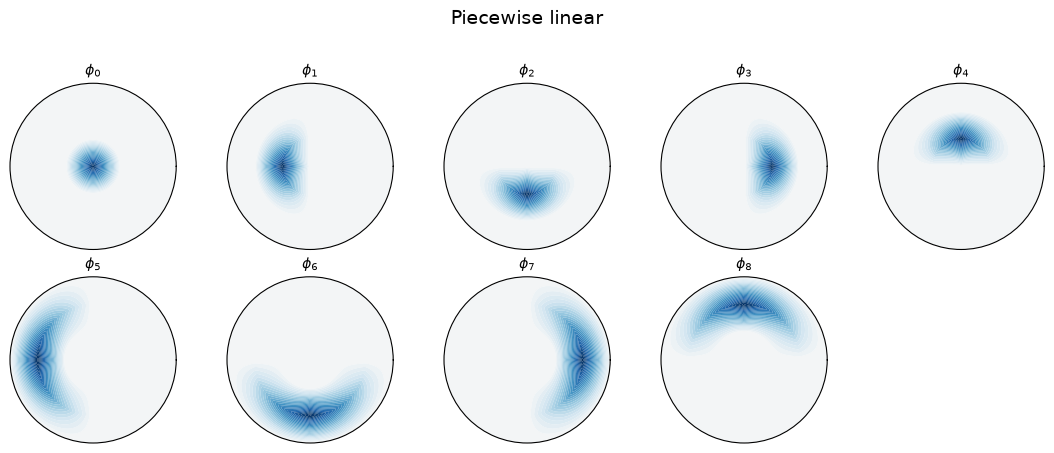

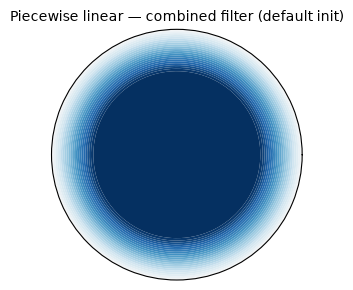

In [2]:
fb_pwl = get_filter_basis((5, 4), "piecewise linear")
print(f"kernel_shape=(5, 4)  =>  K = {fb_pwl.kernel_size} basis functions")
plot_basis(fb_pwl, "Piecewise linear")

### 3.2 Harmonic (Hann-windowed Fourier)

A smooth basis using Hann-windowed sinusoidal modes in the radial direction
and Fourier modes in the angular direction.  The Hann window ensures the
basis functions decay smoothly to zero at the boundary, avoiding
discontinuities.  The basis functions are L2-normalised on the unit disk.

kernel_shape=(3, 3)  =>  K = 9 basis functions


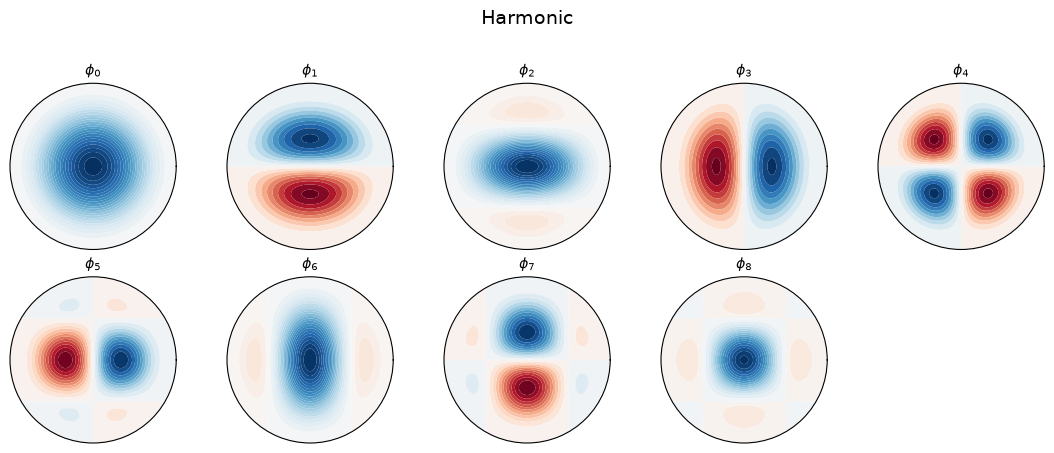

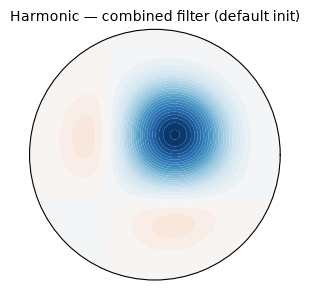

In [3]:
fb_har = get_filter_basis((3, 3), "harmonic")
print(f"kernel_shape=(3, 3)  =>  K = {fb_har.kernel_size} basis functions")
plot_basis(fb_har, "Harmonic")

### 3.3 Zernike polynomials

The [Zernike polynomials](https://en.wikipedia.org/wiki/Zernike_polynomials)
form an orthogonal basis on the unit disk.  They are widely used in optics
and wavefront analysis.  `kernel_shape` is a single integer `n_max`
controlling the maximum radial degree; the total number of basis functions
is $\tfrac{1}{2}(n_{\max}+1)(n_{\max}+2)$.

kernel_shape=4  =>  K = 10 basis functions


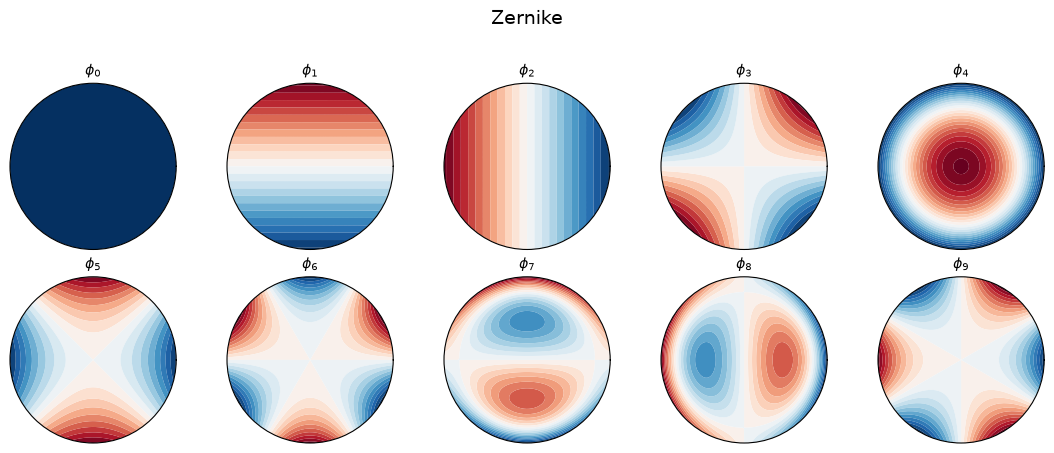

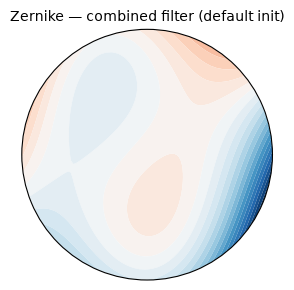

In [4]:
fb_zer = get_filter_basis(4, "zernike")
print(f"kernel_shape=4  =>  K = {fb_zer.kernel_size} basis functions")
plot_basis(fb_zer, "Zernike")

### 3.4 Fourier--Bessel

The Fourier--Bessel basis functions on a disk are defined as

$$
\Psi_{m,n}(r, \varphi) = J_m(\alpha_{m,n}\,r)\,\cos(m\,\varphi)
$$

where $J_m$ is the Bessel function of the first kind and $\alpha_{m,n}$
is its $n$-th positive zero.  Unlike the Zernike polynomials, these basis
functions vanish at the boundary of the disk ($r = 1$), which avoids edge
artefacts in the convolution.

```{note}
This basis requires [SciPy](https://scipy.org/) to be installed.
```

kernel_shape=(4, 3)  =>  K = 20 basis functions


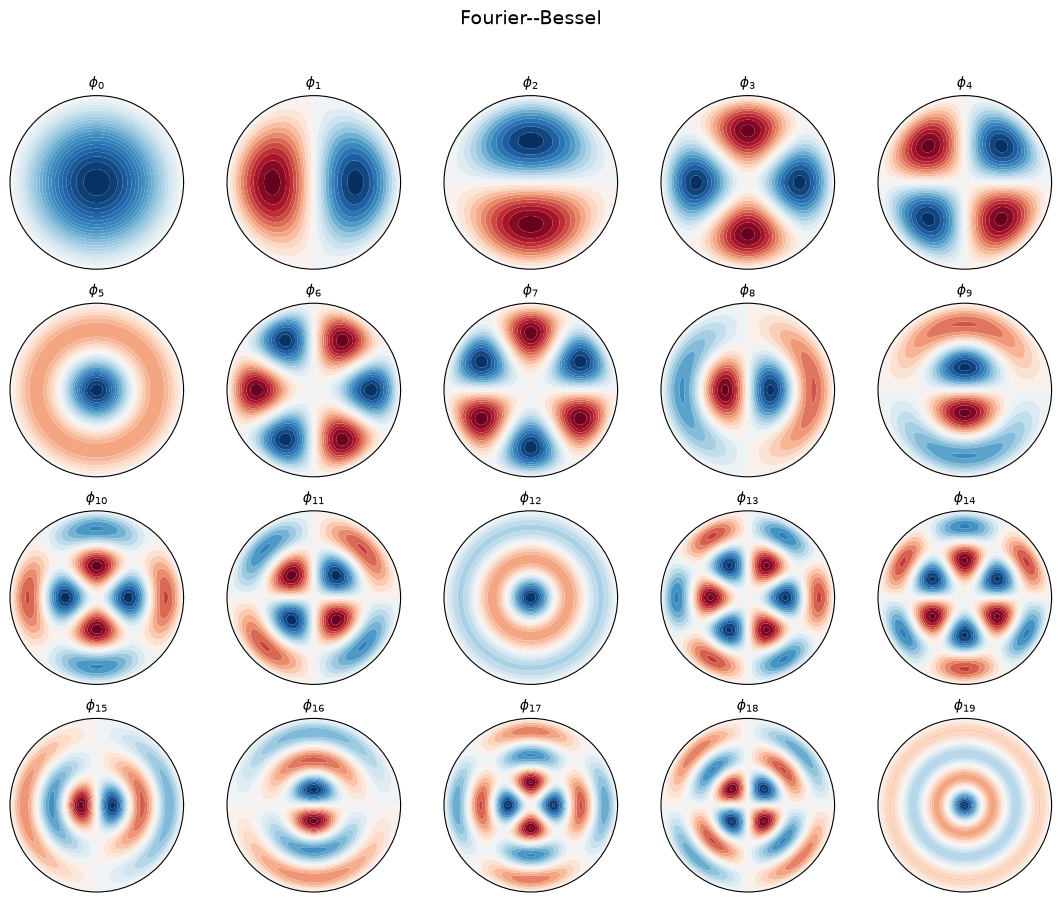

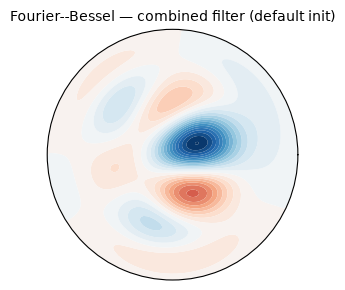

In [5]:
fb_fbs = get_filter_basis((4, 3), "fourier-bessel")
print(f"kernel_shape=(4, 3)  =>  K = {fb_fbs.kernel_size} basis functions")
plot_basis(fb_fbs, "Fourier--Bessel")

## 4. Running a DISCO convolution

With the mathematical background in place, let's run a concrete convolution.
We use the MOLA digital elevation map of Mars (courtesy of NASA) as a
realistic input signal on the sphere and apply a
{class}`~torch_harmonics.DiscreteContinuousConvS2` layer.

In [6]:
import torch.nn.functional as F

import torch_harmonics as th
from torch_harmonics.utils import load_mola_elevation

nlat, nlon = 128, 256
signal = load_mola_elevation(nlat, nlon).unsqueeze(0).unsqueeze(0)

in_channels, out_channels = 1, 8

torch.manual_seed(333)

conv = th.DiscreteContinuousConvS2(
    in_channels=in_channels,
    out_channels=out_channels,
    in_shape=(nlat, nlon),
    out_shape=(nlat, nlon),
    kernel_shape=(5, 4),
    basis_type="piecewise linear",
    theta_cutoff=0.2,
)

y = conv(signal)

print(f"Input shape:  {signal.shape}")
print(f"Output shape: {y.shape}")

Input shape:  torch.Size([1, 1, 128, 256])
Output shape: torch.Size([1, 8, 128, 256])


Let's visualise the input and one output channel:

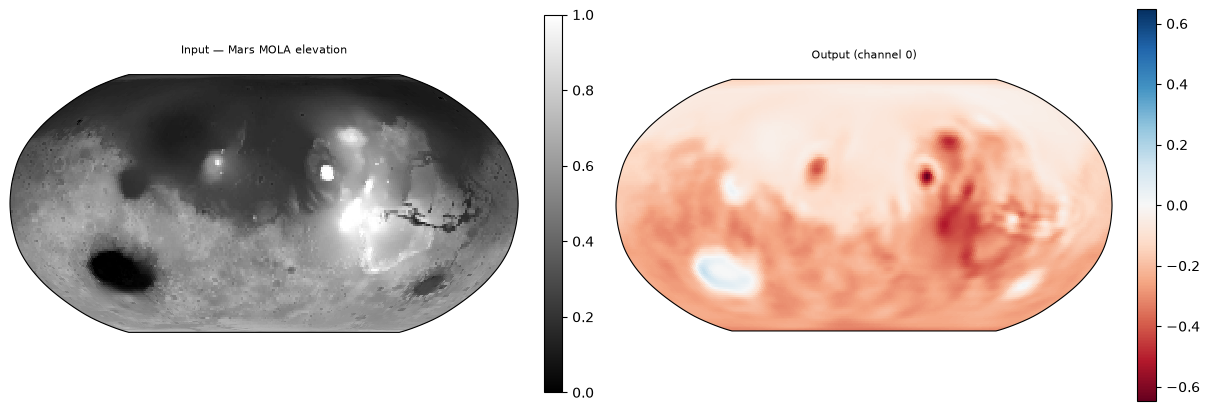

In [7]:
fig = plt.figure(figsize=(12, 4), layout="constrained")
subfigs = fig.subfigures(1, 2)

plot_sphere(signal[0, 0].detach(), fig=subfigs[0], cmap="gray",
            title="Input — Mars MOLA elevation", colorbar=True)

vmax = y[0, 0].abs().max().item()
plot_sphere(y[0, 0].detach(), fig=subfigs[1], cmap="RdBu",
            title="Output (channel 0)", colorbar=True,
            vmin=-vmax, vmax=vmax)

plt.show()

## 5. The $\Psi$ tensor in practice

The precomputed $\Psi$ tensor is stored in COO sparse format on the module.
Let's inspect its sparsity and how it scales with resolution and
`theta_cutoff`.

In [8]:
# sparsity at different resolutions
for nlat, nlon in [(32, 64), (64, 128), (128, 256)]:
    conv_res = th.DiscreteContinuousConvS2(
        in_channels=1, out_channels=1,
        in_shape=(nlat, nlon), out_shape=(nlat, nlon),
        kernel_shape=(5, 4), basis_type="piecewise linear",
    )
    nnz = conv_res.psi_vals.numel()
    total = conv_res.kernel_size * nlat * nlat * nlon
    print(f"Grid {nlat:3d}x{nlon:3d}: "
          f"{nnz:>8,} nonzeros in Psi "
          f"(density {100*nnz/total:.3f}%)")

Grid  32x 64:    1,689 nonzeros in Psi (density 0.286%)
Grid  64x128:    3,549 nonzeros in Psi (density 0.075%)
Grid 128x256:    7,481 nonzeros in Psi (density 0.020%)


In [9]:
# effect of theta_cutoff on the number of nonzeros
nlat, nlon = 64, 128
for tc in [0.05, 0.1, 0.2, 0.4]:
    conv_tc = th.DiscreteContinuousConvS2(
        in_channels=1, out_channels=1,
        in_shape=(nlat, nlon), out_shape=(nlat, nlon),
        kernel_shape=(5, 4), basis_type="piecewise linear",
        theta_cutoff=tc,
    )
    nnz = conv_tc.psi_vals.numel()
    print(f"theta_cutoff={tc:.2f} rad ({math.degrees(tc):5.1f} deg): "
          f"{nnz:>8,} nonzeros")

theta_cutoff=0.05 rad (  2.9 deg):    3,565 nonzeros
theta_cutoff=0.10 rad (  5.7 deg):   10,653 nonzeros
theta_cutoff=0.20 rad ( 11.5 deg):   29,228 nonzeros
theta_cutoff=0.40 rad ( 22.9 deg):   92,846 nonzeros


## 6. Choosing `theta_cutoff` and `kernel_shape`

These are the two main hyperparameters:

- **`theta_cutoff`** controls how far each output point can "see" on the
  sphere.  A larger cutoff increases the receptive field but also increases
  the number of nonzeros in $\Psi$ (and thus cost and memory).  If not
  specified, it defaults to $\pi / (N_{\text{lat,out}} - 1)$, which is
  roughly one grid spacing.

- **`kernel_shape`** controls the number of learnable degrees of freedom per
  channel pair.  More basis functions allow the filter to represent more
  complex spatial patterns, but increase the parameter count.

The interplay between the two matters: a large `theta_cutoff` with too few
basis functions undersamples the filter, while many basis functions crammed
into a tiny support are wasteful.

## 7. Transpose convolution

{class}`~torch_harmonics.DiscreteContinuousConvTransposeS2` applies the
$\Psi$ tensor in the reverse direction, mapping a coarser grid to a finer
one (upsampling).  It uses the same filter basis and compact-support
construction.  This is the adjoint of the forward convolution and is
typically used in decoder / upsampling paths of U-Net-style architectures
on the sphere.

In [10]:
nlat_coarse, nlon_coarse = 64, 128
nlat_fine, nlon_fine = 128, 256

signal_coarse = F.interpolate(signal, size=(nlat_coarse, nlon_coarse),
                              mode="bilinear", align_corners=False)

torch.manual_seed(333)

conv_up = th.DiscreteContinuousConvTransposeS2(
    in_channels=1, out_channels=8,
    in_shape=(nlat_coarse, nlon_coarse),
    out_shape=(nlat_fine, nlon_fine),
    kernel_shape=(5, 4),
    basis_type="piecewise linear",
    theta_cutoff=0.2,
)

y_up = conv_up(signal_coarse)
print(f"Input:  {signal_coarse.shape}")
print(f"Output: {y_up.shape}")

Input:  torch.Size([1, 1, 64, 128])
Output: torch.Size([1, 8, 128, 256])


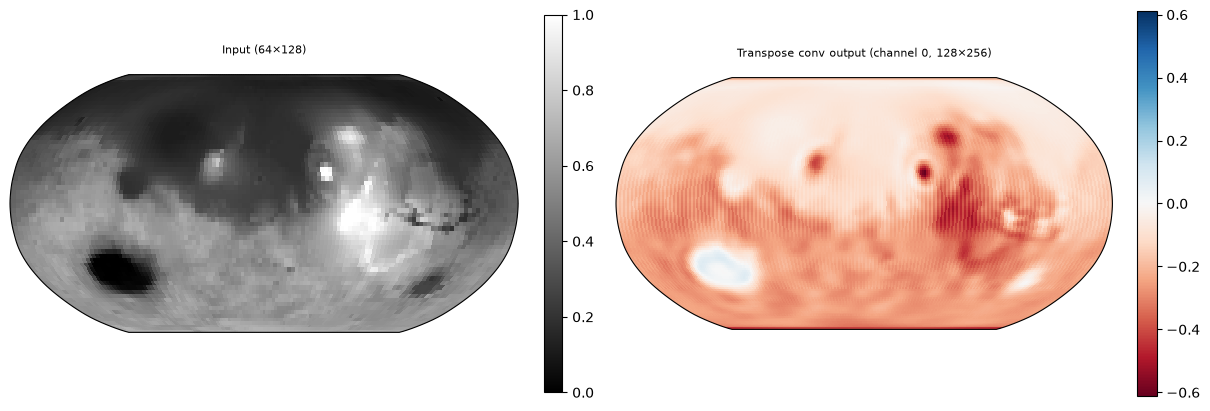

In [11]:
fig = plt.figure(figsize=(12, 4), layout="constrained")
subfigs = fig.subfigures(1, 2)

plot_sphere(signal_coarse[0, 0].detach(), fig=subfigs[0], cmap="gray",
            title=f"Input ({nlat_coarse}×{nlon_coarse})", colorbar=True)

vmax = y_up[0, 0].abs().max().item()
plot_sphere(y_up[0, 0].detach(), fig=subfigs[1], cmap="RdBu",
            title=f"Transpose conv output (channel 0, {nlat_fine}×{nlon_fine})",
            colorbar=True, vmin=-vmax, vmax=vmax)

plt.show()

## Summary

- DISCO convolutions combine a **continuous filter** (learnable weights over
  basis functions) with **discrete quadrature** to achieve $O(N)$ spherical
  convolutions with approximate $SO(3)$ equivariance.
- The precomputed **$\Psi$ tensor** is sparse (compact support) and
  longitude-invariant (p-shift), making the convolution efficient.
- Four **basis types** are available: piecewise linear, harmonic, Zernike,
  and Fourier--Bessel.  The choice affects the smoothness and expressiveness
  of the filter.
- **`theta_cutoff`** and **`kernel_shape`** are the key hyperparameters
  controlling receptive field and filter complexity.

```{tip}
When running on **CPU**, the DISCO convolution kernels are parallelised
with OpenMP.  Setting `OMP_NUM_THREADS` to the number of physical cores
can significantly improve performance.  The optimal thread binding
depends on your hardware:

- `OMP_PROC_BIND=close` packs threads onto adjacent cores, which is
  usually best on single-socket machines where threads benefit from
  shared cache.
- `OMP_PROC_BIND=spread` distributes threads across sockets or chiplets,
  which can be better on multi-socket or AMD EPYC systems where aggregate
  memory bandwidth is the bottleneck.

For Intel OpenMP, the equivalent settings are `KMP_AFFINITY=compact` and
`KMP_AFFINITY=scatter`.

    export OMP_NUM_THREADS=8
    export OMP_PROC_BIND=close   # or spread on multi-socket systems
```

For the full parameter documentation, see the
{class}`~torch_harmonics.DiscreteContinuousConvS2` and
{class}`~torch_harmonics.DiscreteContinuousConvTransposeS2` API pages.